# RDD to DataFrame
Similar to RDDs, DataFrames are immutable and distributed data structures in Spark. Even though RDDs are a fundamental data structure in Spark, working with data in DataFrames is easier than in RDDs. So, understanding of how to convert an RDD to a DataFrame is necessary.

In this exercise, you'll first make an RDD using the sample_list that is already provided to you. This RDD contains a list of tuples ('Mona',20), ('Jennifer',34),('John',20), ('Jim',26) with each tuple containing the name of the person and their age. Next, you'll create a DataFrame using the RDD and schema (which is the list of 'Name' and 'Age') and finally confirm the output is a PySpark DataFrame.

Remember, you already have a SparkContext sc and SparkSession spark available in your workspace.

- Create an RDD from the sample_list.
- Create a PySpark DataFrame using the above RDD and schema.
- Confirm the output as PySpark DataFrame.



In [ ]:
Welcome to
      ____              __
     / __/__  ___ _____/ /__
    _\ \/ _ \/ _ `/ __/  '_/
   /__ / .__/\_,_/_/ /_/\_\   version 3.2.0
      /_/

Using Python version 3.9.7 (default, Sep 10 2021 00:03:59)
Spark context Web UI available at http://19fa29ef-57a2-4285-af0d-75dcffb4a9dd.sessions.sessions.svc.cluster.local:4040
Spark context available as 'sc' (master = local[*], app id = local-1739560377402).
SparkSession available as 'spark'.
[('Mona', 20), ('Jennifer', 34), ('John', 20), ('Jim', 26)]
# Create an RDD from the list
rdd = sc.parallelize(sample_list)

# Create a PySpark DataFrame
names_df = spark.createDataFrame(rdd, schema=['Name', 'Age'])

# Check the type of names_df
print("The type of names_df is", type(names_df))
The type of names_df is <class 'pyspark.sql.dataframe.DataFrame'>

# Loading CSV into DataFrame
In the previous exercise, you have seen a method for creating a DataFrame from an RDD. Generally, loading data from CSV file is the most common method of creating DataFrames. In this exercise, you'll create a PySpark DataFrame from the people.csv file that is already provided to you as a file_path and confirm the created object is a PySpark DataFrame.

Remember, you already have a SparkSession spark and a variable file_path (the path to the people.csv file) available in your workspace.

- Create a DataFrame from file_path variable which is the path to the people.csv file.
- Confirm the output as PySpark DataFrame.

In [ ]:
# Create an DataFrame from file_path
people_df = spark.read.csv(file_path, header=True, inferSchema=True)

# Check the type of people_df
print("The type of people_df is", type(people_df))
The type of people_df is <class 'pyspark.sql.dataframe.DataFrame'>

## Running SQL Queries Programmatically
DataFrames can be easily manipulated using SQL queries in PySpark. The sql() function in a SparkSession enables applications to run SQL queries programmatically and returns the result as another DataFrame. In this exercise, you'll create a temporary table of DataFrame that you have created previously, then construct a query to select the names of the people from the temporary table and assign the result to a new DataFrame.

Remember, you already have a SparkSession spark and a DataFrame available in your workspace.

- Create a temporary table people.
- Construct a query to select the names of the people from the temporary table people.
- Assign the result of Spark's query to a new DataFrame - people_df_names.
- Print the top 10 names of the people from people_df_names DataFrame.

In [ ]:
Welcome to
      ____              __
     / __/__  ___ _____/ /__
    _\ \/ _ \/ _ `/ __/  '_/
   /__ / .__/\_,_/_/ /_/\_\   version 3.2.0
      /_/

Using Python version 3.9.7 (default, Sep 10 2021 00:03:59)
Spark context Web UI available at http://f3e80fd7-6dc8-41d6-9f3b-ba29cf2e1ee8.sessions.sessions.svc.cluster.local:4040
Spark context available as 'sc' (master = local[*], app id = local-1739578042701).
SparkSession available as 'spark'.
# Create a temporary table "people"
people_df.createOrReplaceTempView("people")

# Construct a query to select the names of the people from the temporary table "people"
query = '''SELECT name FROM people'''

# Assign the result of Spark's query to people_df_names
people_df_names = spark.sql(query)

# Print the top 10 names of the people
people_df_names.show(10)
+----------------+
|            name|
+----------------+
|  Penelope Lewis|
|   David Anthony|
|       Ida Shipp|
|    Joanna Moore|
|  Lisandra Ortiz|
|   David Simmons|
|   Edward Hudson|
|    Albert Jones|
|Leonard Cavender|
|  Everett Vadala|
+----------------+
only showing top 10 rows

## SQL queries for filtering Table
In the previous exercise, you have run a simple SQL query on a DataFrame. There are more sophisticated queries you can construct to obtain the result that you want and use it for downstream analysis such as data visualization and Machine Learning. In this exercise, we will use the temporary table people that you have created previously, filter out the rows where the "sex" is male and female and create two DataFrames.

Please note the "solution" is case sensitive for the SQL commands (For example, it only accepts FROM and not from). The "solution" only accepts "==" and not "=".

Remember, you already have a SparkSession spark and a temporary table people available in your workspace.

- Filter the people table to select all rows where sex is female into people_female_df DataFrame.
- Filter the people table to select all rows where sex is male into people_male_df DataFrame.
- Count the number of rows in both people_female and people_male DataFrames.

In [ ]:
# Filter the people table to select female sex 
people_female_df = spark.sql('SELECT * FROM people WHERE sex=="F"')

# Filter the people table DataFrame to select male sex
people_male_df = spark.sql('SELECT * FROM people WHERE sex=="M"')

# Count the number of rows in both people_df_female and people_male_df DataFrames
print("There are {} rows in the people_female_df and {} rows in the people_male_df DataFrames".format(people_female_df.count(), people_male_df.count()))
There are 49014 rows in the people_female_df and 49066 rows in the people_male_df DataFrames

# PySpark DataFrame visualization
Graphical representations or visualization of data is imperative for understanding as well as interpreting the data. In this simple data visualization exercise, you'll first print the column names of names_df DataFrame that you have created earlier, then convert the names_df to Pandas DataFrame, and finally plot the contents as horizontal bar plot with names of the people on the x-axis and their age on the y-axis.

Remember, you already have a SparkSession spark and a DataFrame names_df available in your workspace.

- Print the names of the columns in names_df DataFrame.
- Convert names_df DataFrame to df_pandas Pandas DataFrame.
- Use matplotlib's plot() method to create a horizontal bar plot with 'Name' on x-axis and 'Age' on y-axis.

In [ ]:
Welcome to
      ____              __
     / __/__  ___ _____/ /__
    _\ \/ _ \/ _ `/ __/  '_/
   /__ / .__/\_,_/_/ /_/\_\   version 3.2.0
      /_/

Using Python version 3.9.7 (default, Sep 10 2021 00:03:59)
Spark context Web UI available at http://9f184b06-bd32-4395-b4aa-875a507c8470.sessions.sessions.svc.cluster.local:4040
Spark context available as 'sc' (master = local[*], app id = local-1739840910508).
SparkSession available as 'spark'.
# Check the column names of names_df
print("The column names of names_df are", names_df.columns)

# Convert to Pandas DataFrame  
df_pandas = names_df.toPandas()

# Create a horizontal bar plot
df_pandas.plot(kind='barh', x='Name', y='Age', colormap='winter_r')
plt.show()
The column names of names_df are ['Name', 'Age']

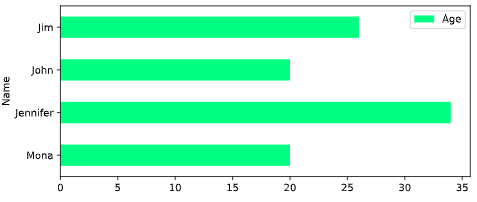

# Part 1: Create a DataFrame from CSV file
Every 4 years, soccer fans throughout the world celebrate a festival called “Fifa World Cup” and with that, everything seems to change in many countries. In this 3 part exercise, you'll be doing some exploratory data analysis (EDA) on the "FIFA 2018 World Cup Player" dataset using PySpark SQL which involves DataFrame operations, SQL queries, and visualization.

In the first part, you'll load FIFA 2018 World Cup Players dataset (Fifa2018_dataset.csv), which is in CSV format, into a PySpark's dataFrame and inspect the data using basic DataFrame operations.

Remember, you already have a SparkSession spark and a variable file_path available in your workspace.

- Create a PySpark DataFrame from file_path (which is the path to the Fifa2018_dataset.csv file).
- Print the schema of the DataFrame.
- Print the first 10 observations.
- How many rows are in there in the DataFrame?

In [ ]:
# Load the Dataframe
fifa_df = spark.read.csv(file_path, header=True, inferSchema=True)

# Check the schema of columns
fifa_df.printSchema()

# Show the first 10 observations
fifa_df.show(10)

# Print the total number of rows
print("There are {} rows in the fifa_df DataFrame".format(fifa_df.count()))
root
 |-- _c0: integer (nullable = true)
 |-- Name: string (nullable = true)
 |-- Age: integer (nullable = true)
 |-- Photo: string (nullable = true)
 |-- Nationality: string (nullable = true)
 |-- Flag: string (nullable = true)
 |-- Overall: integer (nullable = true)
 |-- Potential: integer (nullable = true)
 |-- Club: string (nullable = true)
 |-- Club Logo: string (nullable = true)
 |-- Value: string (nullable = true)
 |-- Wage: string (nullable = true)
 |-- Special: integer (nullable = true)
 |-- Acceleration: string (nullable = true)
 |-- Aggression: string (nullable = true)
 |-- Agility: string (nullable = true)
 |-- Balance: string (nullable = true)
 |-- Ball control: string (nullable = true)
 |-- Composure: string (nullable = true)
 |-- Crossing: string (nullable = true)
 |-- Curve: string (nullable = true)
 |-- Dribbling: string (nullable = true)
 |-- Finishing: string (nullable = true)
 |-- Free kick accuracy: string (nullable = true)
 |-- GK diving: string (nullable = true)
 |-- GK handling: string (nullable = true)
 |-- GK kicking: string (nullable = true)
 |-- GK positioning: string (nullable = true)
 |-- GK reflexes: string (nullable = true)
 |-- Heading accuracy: string (nullable = true)
 |-- Interceptions: string (nullable = true)
 |-- Jumping: string (nullable = true)
 |-- Long passing: string (nullable = true)
 |-- Long shots: string (nullable = true)
 |-- Marking: string (nullable = true)
 |-- Penalties: string (nullable = true)
 |-- Positioning: string (nullable = true)
 |-- Reactions: string (nullable = true)
 |-- Short passing: string (nullable = true)
 |-- Shot power: string (nullable = true)
 |-- Sliding tackle: string (nullable = true)
 |-- Sprint speed: string (nullable = true)
 |-- Stamina: string (nullable = true)
 |-- Standing tackle: string (nullable = true)
 |-- Strength: string (nullable = true)
 |-- Vision: string (nullable = true)
 |-- Volleys: string (nullable = true)
 |-- CAM: double (nullable = true)
 |-- CB: double (nullable = true)
 |-- CDM: double (nullable = true)
 |-- CF: double (nullable = true)
 |-- CM: double (nullable = true)
 |-- ID: integer (nullable = true)
 |-- LAM: double (nullable = true)
 |-- LB: double (nullable = true)
 |-- LCB: double (nullable = true)
 |-- LCM: double (nullable = true)
 |-- LDM: double (nullable = true)
 |-- LF: double (nullable = true)
 |-- LM: double (nullable = true)
 |-- LS: double (nullable = true)
 |-- LW: double (nullable = true)
 |-- LWB: double (nullable = true)
 |-- Preferred Positions: string (nullable = true)
 |-- RAM: double (nullable = true)
 |-- RB: double (nullable = true)
 |-- RCB: double (nullable = true)
 |-- RCM: double (nullable = true)
 |-- RDM: double (nullable = true)
 |-- RF: double (nullable = true)
 |-- RM: double (nullable = true)
 |-- RS: double (nullable = true)
 |-- RW: double (nullable = true)
 |-- RWB: double (nullable = true)
 |-- ST: double (nullable = true)

+---+-----------------+---+--------------------+-----------+--------------------+-------+---------+-------------------+--------------------+------+-----+-------+------------+----------+-------+-------+------------+---------+--------+-----+---------+---------+------------------+---------+-----------+----------+--------------+-----------+----------------+-------------+-------+------------+----------+-------+---------+-----------+---------+-------------+----------+--------------+------------+-------+---------------+--------+------+-------+----+----+----+----+----+------+----+----+----+----+----+----+----+----+----+----+-------------------+----+----+----+----+----+----+----+----+----+----+----+
|_c0|             Name|Age|               Photo|Nationality|                Flag|Overall|Potential|               Club|           Club Logo| Value| Wage|Special|Acceleration|Aggression|Agility|Balance|Ball control|Composure|Crossing|Curve|Dribbling|Finishing|Free kick accuracy|GK diving|GK handling|GK kicking|GK positioning|GK reflexes|Heading accuracy|Interceptions|Jumping|Long passing|Long shots|Marking|Penalties|Positioning|Reactions|Short passing|Shot power|Sliding tackle|Sprint speed|Stamina|Standing tackle|Strength|Vision|Volleys| CAM|  CB| CDM|  CF|  CM|    ID| LAM|  LB| LCB| LCM| LDM|  LF|  LM|  LS|  LW| LWB|Preferred Positions| RAM|  RB| RCB| RCM| RDM|  RF|  RM|  RS|  RW| RWB|  ST|
+---+-----------------+---+--------------------+-----------+--------------------+-------+---------+-------------------+--------------------+------+-----+-------+------------+----------+-------+-------+------------+---------+--------+-----+---------+---------+------------------+---------+-----------+----------+--------------+-----------+----------------+-------------+-------+------------+----------+-------+---------+-----------+---------+-------------+----------+--------------+------------+-------+---------------+--------+------+-------+----+----+----+----+----+------+----+----+----+----+----+----+----+----+----+----+-------------------+----+----+----+----+----+----+----+----+----+----+----+
|  0|Cristiano Ronaldo| 32|https://cdn.sofif...|   Portugal|https://cdn.sofif...|     94|       94|     Real Madrid CF|https://cdn.sofif...|€95.5M|€565K|   2228|          89|        63|     89|     63|          93|       95|      85|   81|       91|       94|                76|        7|         11|        15|            14|         11|              88|           29|     95|          77|        92|     22|       85|         95|       96|           83|        94|            23|          91|     92|             31|      80|    85|     88|89.0|53.0|62.0|91.0|82.0| 20801|89.0|61.0|53.0|82.0|62.0|91.0|89.0|92.0|91.0|66.0|             ST LW |89.0|61.0|53.0|82.0|62.0|91.0|89.0|92.0|91.0|66.0|92.0|
|  1|         L. Messi| 30|https://cdn.sofif...|  Argentina|https://cdn.sofif...|     93|       93|       FC Barcelona|https://cdn.sofif...| €105M|€565K|   2154|          92|        48|     90|     95|          95|       96|      77|   89|       97|       95|                90|        6|         11|        15|            14|          8|              71|           22|     68|          87|        88|     13|       74|         93|       95|           88|        85|            26|          87|     73|             28|      59|    90|     85|92.0|45.0|59.0|92.0|84.0|158023|92.0|57.0|45.0|84.0|59.0|92.0|90.0|88.0|91.0|62.0|                RW |92.0|57.0|45.0|84.0|59.0|92.0|90.0|88.0|91.0|62.0|88.0|
|  2|           Neymar| 25|https://cdn.sofif...|     Brazil|https://cdn.sofif...|     92|       94|Paris Saint-Germain|https://cdn.sofif...| €123M|€280K|   2100|          94|        56|     96|     82|          95|       92|      75|   81|       96|       89|                84|        9|          9|        15|            15|         11|              62|           36|     61|          75|        77|     21|       81|         90|       88|           81|        80|            33|          90|     78|             24|      53|    80|     83|88.0|46.0|59.0|88.0|79.0|190871|88.0|59.0|46.0|79.0|59.0|88.0|87.0|84.0|89.0|64.0|                LW |88.0|59.0|46.0|79.0|59.0|88.0|87.0|84.0|89.0|64.0|84.0|
|  3|        L. Suárez| 30|https://cdn.sofif...|    Uruguay|https://cdn.sofif...|     92|       92|       FC Barcelona|https://cdn.sofif...|  €97M|€510K|   2291|          88|        78|     86|     60|          91|       83|      77|   86|       86|       94|                84|       27|         25|        31|            33|         37|              77|           41|     69|          64|        86|     30|       85|         92|       93|           83|        87|            38|          77|     89|             45|      80|    84|     88|87.0|58.0|65.0|88.0|80.0|176580|87.0|64.0|58.0|80.0|65.0|88.0|85.0|88.0|87.0|68.0|                ST |87.0|64.0|58.0|80.0|65.0|88.0|85.0|88.0|87.0|68.0|88.0|
|  4|         M. Neuer| 31|https://cdn.sofif...|    Germany|https://cdn.sofif...|     92|       92|   FC Bayern Munich|https://cdn.sofif...|  €61M|€230K|   1493|          58|        29|     52|     35|          48|       70|      15|   14|       30|       13|                11|       91|         90|        95|            91|         89|              25|           30|     78|          59|        16|     10|       47|         12|       85|           55|        25|            11|          61|     44|             10|      83|    70|     11|null|null|null|null|null|167495|null|null|null|null|null|null|null|null|null|null|                GK |null|null|null|null|null|null|null|null|null|null|null|
|  5|   R. Lewandowski| 28|https://cdn.sofif...|     Poland|https://cdn.sofif...|     91|       91|   FC Bayern Munich|https://cdn.sofif...|  €92M|€355K|   2143|          79|        80|     78|     80|          89|       87|      62|   77|       85|       91|                84|       15|          6|        12|             8|         10|              85|           39|     84|          65|        83|     25|       81|         91|       91|           83|        88|            19|          83|     79|             42|      84|    78|     87|84.0|57.0|62.0|87.0|78.0|188545|84.0|58.0|57.0|78.0|62.0|87.0|82.0|88.0|84.0|61.0|                ST |84.0|58.0|57.0|78.0|62.0|87.0|82.0|88.0|84.0|61.0|88.0|
|  6|           De Gea| 26|https://cdn.sofif...|      Spain|https://cdn.sofif...|     90|       92|  Manchester United|https://cdn.sofif...|€64.5M|€215K|   1458|          57|        38|     60|     43|          42|       64|      17|   21|       18|       13|                19|       90|         85|        87|            86|         90|              21|           30|     67|          51|        12|     13|       40|         12|       88|           50|        31|            13|          58|     40|             21|      64|    68|     13|null|null|null|null|null|193080|null|null|null|null|null|null|null|null|null|null|                GK |null|null|null|null|null|null|null|null|null|null|null|
|  7|        E. Hazard| 26|https://cdn.sofif...|    Belgium|https://cdn.sofif...|     90|       91|            Chelsea|https://cdn.sofif...|€90.5M|€295K|   2096|          93|        54|     93|     91|          92|       87|      80|   82|       93|       83|                79|       11|         12|         6|             8|          8|              57|           41|     59|          81|        82|     25|       86|         85|       85|           86|        79|            22|          87|     79|             27|      65|    86|     79|88.0|47.0|61.0|87.0|81.0|183277|88.0|59.0|47.0|81.0|61.0|87.0|87.0|82.0|88.0|64.0|                LW |88.0|59.0|47.0|81.0|61.0|87.0|87.0|82.0|88.0|64.0|82.0|
|  8|         T. Kroos| 27|https://cdn.sofif...|    Germany|https://cdn.sofif...|     90|       90|     Real Madrid CF|https://cdn.sofif...|  €79M|€340K|   2165|          60|        60|     71|     69|          89|       85|      85|   85|       79|       76|                84|       10|         11|        13|             7|         10|              54|           85|     32|          93|        90|     63|       73|         79|       86|           90|        87|            69|          52|     77|             82|      74|    88|     82|83.0|72.0|82.0|81.0|87.0|182521|83.0|76.0|72.0|87.0|82.0|81.0|81.0|77.0|80.0|78.0|            CDM CM |83.0|76.0|72.0|87.0|82.0|81.0|81.0|77.0|80.0|78.0|77.0|
|  9|       G. Higuaín| 29|https://cdn.sofif...|  Argentina|https://cdn.sofif...|     90|       90|           Juventus|https://cdn.sofif...|  €77M|€275K|   1961|          78|        50|     75|     69|          85|       86|      68|   74|       84|       91|                62|        5|         12|         7|             5|         10|              86|           20|     79|          59|        82|     12|       70|         92|       88|           75|        88|            18|          80|     72|             22|      85|    70|     88|81.0|46.0|52.0|84.0|71.0|167664|81.0|51.0|46.0|71.0|52.0|84.0|79.0|87.0|82.0|55.0|                ST |81.0|51.0|46.0|71.0|52.0|84.0|79.0|87.0|82.0|55.0|87.0|
+---+-----------------+---+--------------------+-----------+--------------------+-------+---------+-------------------+--------------------+------+-----+-------+------------+----------+-------+-------+------------+---------+--------+-----+---------+---------+------------------+---------+-----------+----------+--------------+-----------+----------------+-------------+-------+------------+----------+-------+---------+-----------+---------+-------------+----------+--------------+------------+-------+---------------+--------+------+-------+----+----+----+----+----+------+----+----+----+----+----+----+----+----+----+----+-------------------+----+----+----+----+----+----+----+----+----+----+----+
only showing top 10 rows

There are 17981 rows in the fifa_df DataFrame

# Part 2: SQL Queries on DataFrame
The fifa_df DataFrame that we created has additional information about datatypes and names of columns associated with it. This additional information allows PySpark SQL to run SQL queries on DataFrame. SQL queries are concise and easy to run compared to DataFrame operations. But in order to apply SQL queries on DataFrame first, you need to create a temporary view of DataFrame as a table and then apply SQL queries on the created table (Running SQL Queries Programmatically).

In the second part, you'll create a temporary table of fifa_df DataFrame and run SQL queries to extract the 'Age' column of players from Germany.

You already have a SparkContext spark and fifa_df available in your workspace.

- Create temporary table fifa_df_table from fifa_df DataFrame.
- Construct a "query" to extract the "Age" column from Germany players in fifa_df_table.
- Apply the SQL "query" and create a new DataFrame fifa_df_germany_age.
- Computes basic statistics of the created DataFrame.

In [ ]:
Welcome to
      ____              __
     / __/__  ___ _____/ /__
    _\ \/ _ \/ _ `/ __/  '_/
   /__ / .__/\_,_/_/ /_/\_\   version 3.2.0
      /_/

Using Python version 3.9.7 (default, Sep 10 2021 00:03:59)
Spark context Web UI available at http://9f184b06-bd32-4395-b4aa-875a507c8470.sessions.sessions.svc.cluster.local:4040
Spark context available as 'sc' (master = local[*], app id = local-1739841298025).
SparkSession available as 'spark'.
# Create a temporary view of fifa_df
fifa_df.createOrReplaceTempView('fifa_df_table')

# Construct the "query"
query = '''SELECT Age FROM fifa_df_table WHERE Nationality == "Germany"'''

# Apply the SQL "query"
fifa_df_germany_age = spark.sql(query)

# Generate basic statistics
fifa_df_germany_age.describe().show()
ERROR! Session/line number was not unique in database. History logging moved to new session 4
+-------+-----------------+
|summary|              Age|
+-------+-----------------+
|  count|             1140|
|   mean|24.20263157894737|
| stddev|4.197096712293756|
|    min|               16|
|    25%|               21|
|    50%|               24|
|    75%|               27|
|    max|               36|
+-------+-----------------+

# Part 3: Data visualization
Data visualization is important for exploratory data analysis (EDA). PySpark DataFrame is perfect for data visualization compared to RDDs because of its inherent structure and schema.

In this third part, you'll create a histogram of the ages of all the players from Germany from the DataFrame that you created in the previous exercise. For this, you'll first convert the PySpark DataFrame into Pandas DataFrame and use matplotlib's plot() function to create a density plot of ages of all players from Germany.

Remember, you already have a SparkSession spark, a temporary table fifa_df_table and a DataFrame fifa_df_germany_age available in your workspace.

- Convert fifa_df_germany_age to fifa_df_germany_age_pandas Pandas DataFrame.
- Generate a density plot of the 'Age' column from the fifa_df_germany_age_pandas Pandas DataFrame.

In [ ]:
Welcome to
      ____              __
     / __/__  ___ _____/ /__
    _\ \/ _ \/ _ `/ __/  '_/
   /__ / .__/\_,_/_/ /_/\_\   version 3.2.0
      /_/

Using Python version 3.9.7 (default, Sep 10 2021 00:03:59)
Spark context Web UI available at http://9f184b06-bd32-4395-b4aa-875a507c8470.sessions.sessions.svc.cluster.local:4040
Spark context available as 'sc' (master = local[*], app id = local-1739841455069).
SparkSession available as 'spark'.
# Convert fifa_df to fifa_df_germany_age_pandas DataFrame
fifa_df_germany_age_pandas = fifa_df_germany_age.toPandas()

# Plot the 'Age' density of Germany Players
fifa_df_germany_age_pandas.plot(kind='density')
plt.show()
ERROR! Session/line number was not unique in database. History logging moved to new session 6

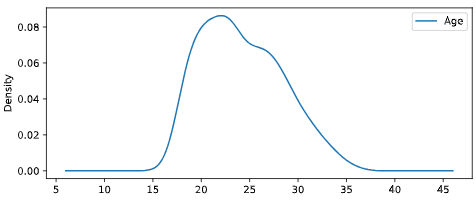